## Exploratory Data Analysis

### Vissualization : Top 10 Buildings

In [6]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

df = pd.read_csv("../reports/cleaned_data.csv")

# Convert timestamp back to datetime

df["timestamp"] = pd.to_datetime(df["timestamp"])

df.head()

,building_id,meter,timestamp,meter_reading,site_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,primary_use,square_feet,year_built,month,quarter,day,energy_intensity,co2_emissions
0,1020,0,2016-11-02 00:00:00,86.6301,10,8.9,4.0,3.3,0.0,1016.5,350.0,3.6,Entertainment/public assembly,22101,NaN,11,4,2,0.003920,37.250943
1,987,2,2016-10-04 00:00:00,228.7500,9,27.8,0.0,15.6,0.0,1010.0,110.0,2.6,Education,166395,NaN,10,4,4,0.001375,98.362500
2,113,0,2016-01-17 19:00:00,335.6250,1,3.6,0.0,1.5,0.0,1023.0,120.0,4.6,Education,100481,1958.0,1,1,17,0.003340,144.318750
3,293,0,2016-07-07 05:00:00,777.2200,3,27.2,0.0,24.4,0.0,1011.0,170.0,3.1,Office,408000,2010.0,7,3,7,0.001905,334.204600
4,1176,2,2016-06-26 15:00:00,238.2810,13,25.0,2.0,10.0,0.0,1014.5,250.0,5.1,Education,142672,NaN,6,2,26,0.001670,102.460830


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 409
Columns: 20
<class 'pandas.DataFrame'>
RangeIndex: 409 entries, 0 to 408
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   building_id         409 non-null    int64         
 1   meter               409 non-null    int64         
 2   timestamp           409 non-null    datetime64[us]
 3   meter_reading       409 non-null    float64       
 4   site_id             409 non-null    int64         
 5   air_temperature     409 non-null    float64       
 6   cloud_coverage      409 non-null    float64       
 7   dew_temperature     409 non-null    float64       
 8   precip_depth_1_hr   409 non-null    float64       
 9   sea_level_pressure  409 non-null    float64       
 10  wind_direction      409 non-null    float64       
 11  wind_speed          409 non-null    float64       
 12  primary_use         409 non-null    str           
 13  square_feet         409 non-null    int

In [8]:
df.describe()

,building_id,meter,timestamp,meter_reading,site_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,square_feet,year_built,month,quarter,day,energy_intensity,co2_emissions
count,409.000000,409.000000,409,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000,164.00000,409.000000,409.000000,409.000000,409.000000,409.000000
mean,810.437653,0.667482,2016-06-30 03:34:02.053789,360.381163,8.158924,15.656235,1.017115,7.103423,0.841076,1016.210269,164.608802,3.284352,106600.843521,1966.79878,6.466993,2.491443,15.327628,0.003213,154.963900
min,7.000000,0.000000,2016-01-01 01:00:00,0.000000,0.000000,-20.000000,0.000000,-24.400000,-1.000000,998.000000,0.000000,0.000000,356.000000,1900.00000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,379.000000,0.000000,2016-03-25 01:00:00,18.490000,3.000000,7.800000,0.000000,-1.100000,0.000000,1012.500000,80.000000,2.100000,31614.000000,1950.00000,3.000000,1.000000,8.000000,0.000528,7.950700
50%,920.000000,0.000000,2016-07-05 11:00:00,84.000000,9.000000,16.700000,0.000000,7.200000,0.000000,1016.500000,165.000000,3.100000,69876.000000,1967.00000,7.000000,3.000000,15.000000,0.001438,36.120000
75%,1185.000000,1.000000,2016-10-01 13:00:00,285.111000,13.000000,24.400000,2.000000,15.600000,0.000000,1020.500000,260.000000,4.100000,133100.000000,1991.00000,10.000000,4.000000,23.000000,0.002967,122.597730
max,1442.000000,3.000000,2016-12-30 15:00:00,7978.500000,15.000000,43.300000,9.000000,25.000000,191.000000,1038.000000,360.000000,12.400000,764237.000000,2016.00000,12.000000,4.000000,31.000000,0.046020,3430.755000
std,426.820314,0.921925,NaN,848.988751,5.048944,11.122657,2.044169,10.486377,9.882976,6.428322,108.617509,2.189413,115012.956370,30.53494,3.580244,1.142130,9.035618,0.005671,365.065163


## Total Energy Consumption

In [9]:
total_energy = df["meter_reading"].sum()

print(
    f"Total Energy Consumption: {total_energy:,.2f}"
)

Total Energy Consumption: 147,395.90


## Carbon Emission

In [10]:
total_emissions = (
    df["co2_emissions"].sum()
)

print(
    f"Total CO2 Emissions: {total_emissions:,.2f}"
)

Total CO2 Emissions: 63,380.24


## Monthly Energy Trend

In [11]:
df["month"] = (
    df["timestamp"]
      .dt.month_name()
)

In [12]:
monthly_energy = (
    df.groupby("month")
      ["meter_reading"]
      .sum()
      .sort_values(
          ascending=False
      )
)

monthly_energy

month
August       26447.7732
January      19996.0196
December     14697.6073
June         14409.9673
July         13981.8715
March        12870.6774
May          12291.0350
February     10601.7534
October       6737.5915
April         6451.3919
September     4692.2703
November      4217.9374
Name: meter_reading, dtype: float64

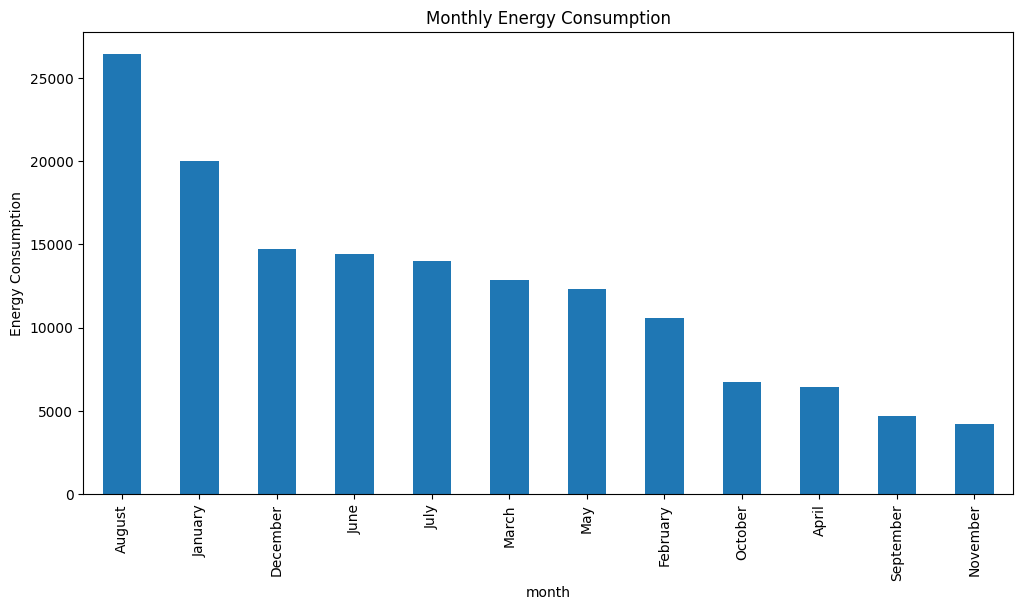

In [13]:
monthly_energy.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Monthly Energy Consumption"
)

plt.ylabel(
    "Energy Consumption"
)

plt.show()

## Top buildings

In [14]:
top_buildings = (
    df.groupby("building_id")
      ["meter_reading"]
      .sum()
      .sort_values(
          ascending=False
      )
      .head(10)
)

top_buildings

building_id
1108    7978.50
1072    5636.72
7       5571.77
1100    5531.25
1331    4971.84
1168    3844.93
792     3516.21
1321    3294.32
1018    3193.91
1258    3180.45
Name: meter_reading, dtype: float64

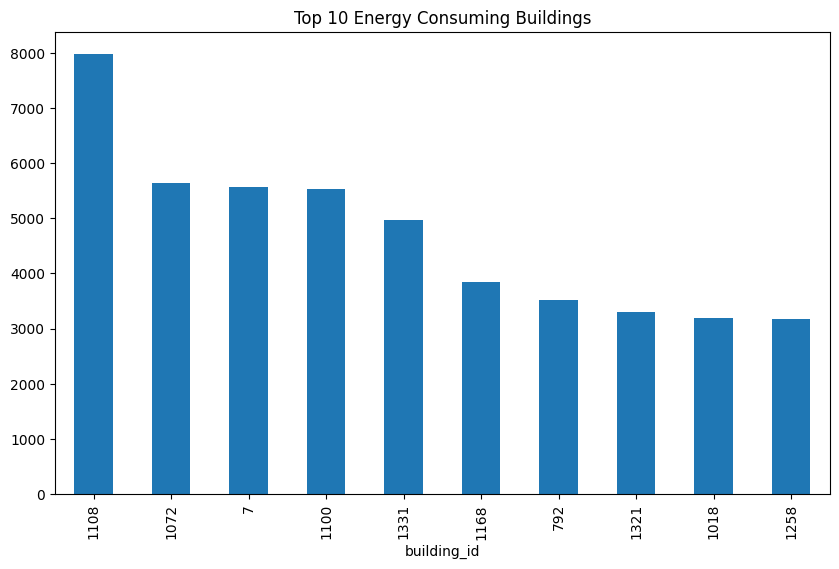

In [15]:
top_buildings.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Top 10 Energy Consuming Buildings"
)

plt.show()

## Consumption by Building type 

In [16]:
building_type = (
    df.groupby("primary_use")
      ["meter_reading"]
      .sum()
      .sort_values(
          ascending=False
      )
)

building_type

primary_use
Education                        64303.9065
Office                           24907.6741
Lodging/residential              15841.7741
Entertainment/public assembly    12925.1204
Public services                  11134.2950
Parking                           8001.2360
Healthcare                        6889.3297
Food sales and service            2057.9000
Utility                            600.4125
Manufacturing/industrial           537.5050
Other                              114.4167
Services                            62.3600
Warehouse/storage                   11.8333
Retail                               8.1325
Name: meter_reading, dtype: float64

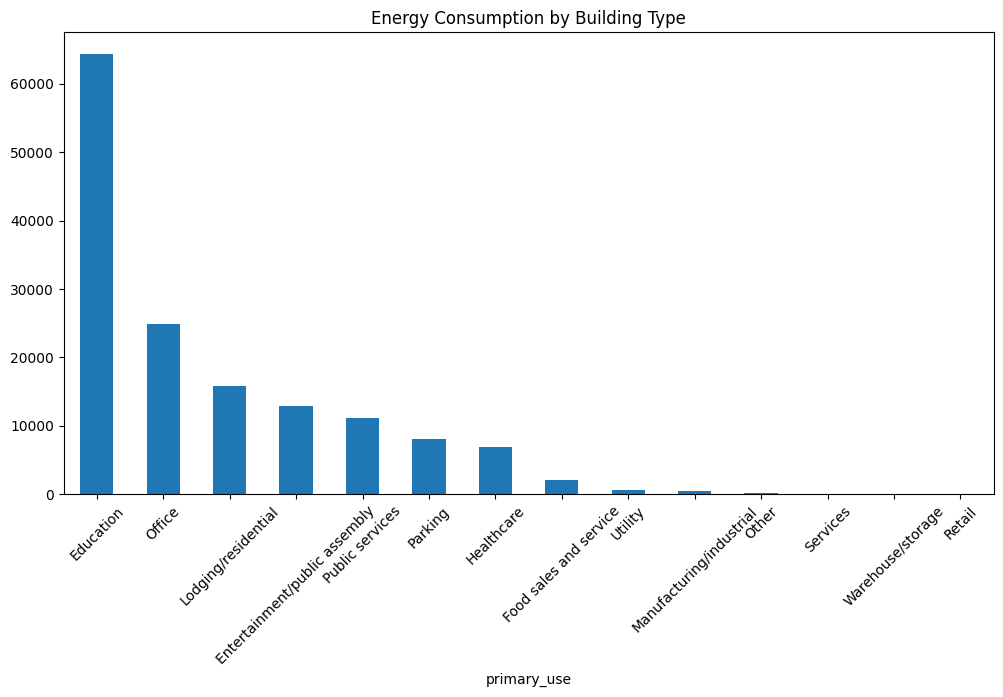

In [17]:
building_type.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Energy Consumption by Building Type"
)

plt.xticks(rotation=45)

plt.show()

## Temperature Vs Energy Consumption 

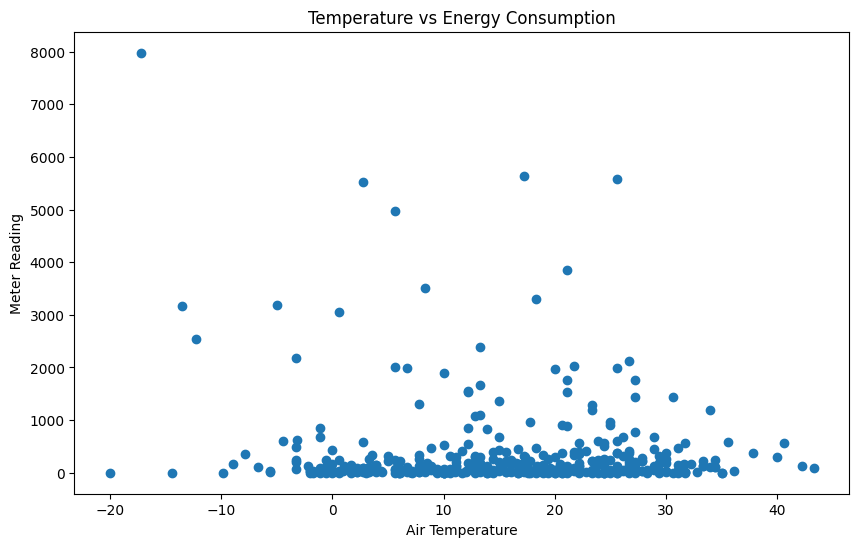

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["air_temperature"],
    df["meter_reading"]
)

plt.xlabel(
    "Air Temperature"
)

plt.ylabel(
    "Meter Reading"
)

plt.title(
    "Temperature vs Energy Consumption"
)

plt.show()

In [19]:
df[
    [
        "meter_reading",
        "air_temperature"
    ]
].corr()

,meter_reading,air_temperature
meter_reading,1.000000,-0.111413
air_temperature,-0.111413,1.000000


Does higher temperature increase energy demand?

## Building Size Vs Consumption

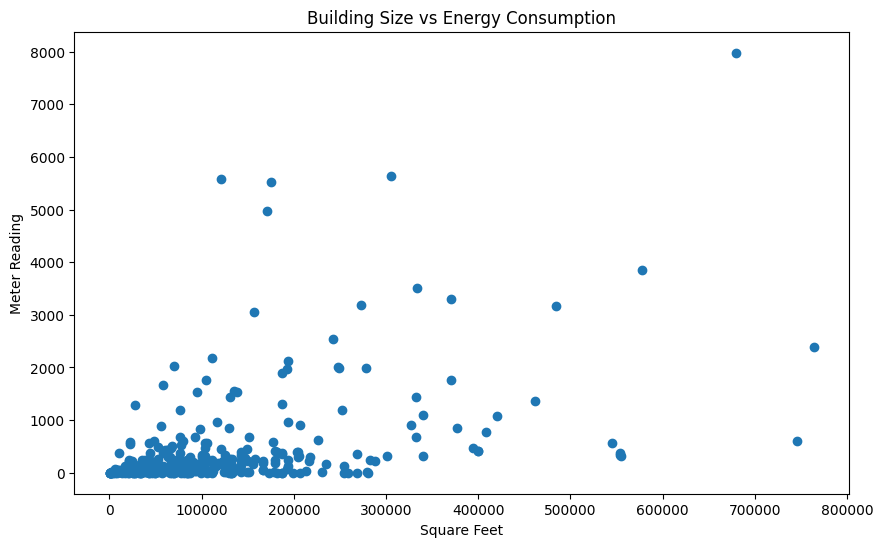

In [20]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["square_feet"],
    df["meter_reading"]
)

plt.xlabel(
    "Square Feet"
)

plt.ylabel(
    "Meter Reading"
)

plt.title(
    "Building Size vs Energy Consumption"
)

plt.show()

In [21]:
df[
    [
        "square_feet",
        "meter_reading"
    ]
].corr()

,square_feet,meter_reading
square_feet,1.000000,0.487673
meter_reading,0.487673,1.000000


Do larger buildings consume more energy?

## Energy Intensity KPI

In [22]:
df["energy_intensity"] = (
    df["meter_reading"]
    /
    df["square_feet"]
)

### Top inneficient Buildings

In [23]:
energy_intensity = (
    df.groupby("building_id")
      ["energy_intensity"]
      .mean()
      .sort_values(
          ascending=False
      )
      .head(10)
)

energy_intensity

building_id
7       0.046020
82      0.035362
1100    0.031621
1331    0.029074
1247    0.029009
1292    0.028651
1230    0.025835
285     0.024867
1437    0.019553
1186    0.019498
Name: energy_intensity, dtype: float64

In [24]:
df.to_csv(
    "../reports/final_energy_analysis.csv", index=False
)